In [3]:
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

# Khởi tạo Spark Session
spark = SparkSession.builder \
    .appName("Olist_E-commerce_Exploration") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print(f"Spark Session đã sẵn sàng. Phiên bản: {spark.version}")

Spark Session đã sẵn sàng. Phiên bản: 3.5.8


In [4]:
# Đường dẫn tới thư mục chứa dữ liệu gốc 
DATA_PATH = "file:///E:/Hoctap/Big data/BTL/data/external/"

# Danh sách các file cần load
files = {
    "orders": "olist_orders_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "products": "olist_products_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "translations": "product_category_name_translation.csv"
}

In [5]:
# Dictionary để lưu trữ các DataFrame
dfs = {}

for name, filename in files.items():
    full_path = os.path.join(DATA_PATH, filename)
    dfs[name] = spark.read.csv(full_path, header=True, inferSchema=True)
    print(f"Đã load bảng: {name} | Số dòng: {dfs[name].count()}")

# Xem thử schema của bảng orders
dfs['orders'].printSchema()

Đã load bảng: orders | Số dòng: 99441
Đã load bảng: items | Số dòng: 112650
Đã load bảng: customers | Số dòng: 99441
Đã load bảng: products | Số dòng: 32951
Đã load bảng: payments | Số dòng: 103886
Đã load bảng: reviews | Số dòng: 104162
Đã load bảng: translations | Số dòng: 71
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)



In [6]:
# Danh sách các cột thời gian trong bảng orders
time_columns = [
    "order_purchase_timestamp", "order_approved_at", 
    "order_delivered_carrier_date", "order_delivered_customer_date", 
    "order_estimated_delivery_date"
]

for col in time_columns:
    dfs['orders'] = dfs['orders'].withColumn(col, F.to_timestamp(F.col(col)))

print("Đã chuyển đổi các cột thời gian thành công.")
dfs['orders'].select(time_columns).limit(5).show()

Đã chuyển đổi các cột thời gian thành công.
+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|     2017-10-02 10:56:33|2017-10-02 11:07:15|         2017-10-04 19:55:00|          2017-10-10 21:25:13|          2017-10-18 00:00:00|
|     2018-07-24 20:41:37|2018-07-26 03:24:27|         2018-07-26 14:31:00|          2018-08-07 15:27:45|          2018-08-13 00:00:00|
|     2018-08-08 08:38:49|2018-08-08 08:55:23|         2018-08-08 13:50:00|          2018-08-17 18:06:29|          2018-09-04 00:00:00|
|     2017-11-18 19:28:06|2017-11-18 19:45:59|         2017-11-22 13:39:59|          2017-12-02 00:28:42|          2017-12-15 00:00:00|
|   

In [7]:
# Join các bảng
analysis_df = dfs['items'] \
    .join(dfs['products'], "product_id") \
    .join(dfs['translations'], "product_category_name")

# Tính tổng doanh thu 
top_categories = analysis_df.groupBy("product_category_name_english") \
    .agg(F.sum("price").alias("total_revenue")) \
    .orderBy(F.desc("total_revenue")) \
    .limit(10)

top_categories.show()

+-----------------------------+------------------+
|product_category_name_english|     total_revenue|
+-----------------------------+------------------+
|                health_beauty|1258681.3399999938|
|                watches_gifts| 1205005.679999998|
|               bed_bath_table|1036988.6799999807|
|               sports_leisure| 988048.9699999837|
|         computers_accesso...|  911954.319999988|
|              furniture_decor| 729762.4899999866|
|                   cool_stuff| 635290.8499999974|
|                   housewares| 632248.6599999928|
|                         auto|  592720.109999997|
|                 garden_tools|485256.45999999647|
+-----------------------------+------------------+



C:\Users\Admin\AppData\Local\Temp\ipykernel_27216\801806668.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_revenue', y='product_category_name_english', data=pdf, palette='viridis')


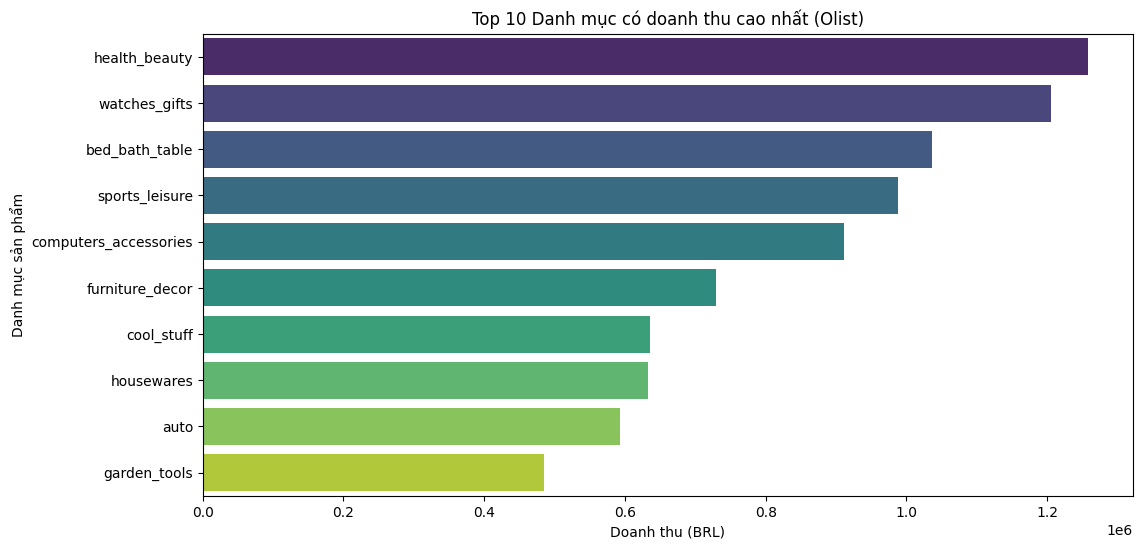

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chuyển kết quả top 10 về Pandas
pdf = top_categories.toPandas()

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.barplot(x='total_revenue', y='product_category_name_english', data=pdf, palette='viridis')
plt.title('Top 10 Danh mục có doanh thu cao nhất (Olist)')
plt.xlabel('Doanh thu (BRL)')
plt.ylabel('Danh mục sản phẩm')
plt.show()

In [9]:
# Join các bảng
analysis_df = dfs['items'] \
    .join(dfs['products'], "product_id") \
    .join(dfs['translations'], "product_category_name")

# Tính tổng doanh thu 
top_categories = analysis_df.groupBy("product_category_name_english") \
    .agg(F.sum("price").alias("total_revenue")) \
    .orderBy(F.desc("total_revenue")) \
    .limit(10)

top_categories.show()

+-----------------------------+------------------+
|product_category_name_english|     total_revenue|
+-----------------------------+------------------+
|                health_beauty|1258681.3399999938|
|                watches_gifts| 1205005.679999998|
|               bed_bath_table|1036988.6799999807|
|               sports_leisure| 988048.9699999837|
|         computers_accesso...|  911954.319999988|
|              furniture_decor| 729762.4899999866|
|                   cool_stuff| 635290.8499999974|
|                   housewares| 632248.6599999928|
|                         auto|  592720.109999997|
|                 garden_tools|485256.45999999647|
+-----------------------------+------------------+



In [10]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# 1. Khởi tạo Spark
spark = SparkSession.builder \
    .appName("Data_Inflator") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# 2. Đường dẫn dữ liệu
INPUT_PATH = "../external/olist_orders_dataset.csv"
OUTPUT_PATH = "../processed/inflated_orders"

df_original = spark.read.csv(INPUT_PATH, header=True, inferSchema=True)

time_cols = [c for c in df_original.columns if 'timestamp' in c or 'date' in c]
for col in time_cols:
    df_original = df_original.withColumn(col, F.to_timestamp(F.col(col)))

# 3. Nhân bản 10x với biến động thời gian
REPLICATION_FACTOR = 30
inflated_df = None

for i in range(REPLICATION_FACTOR):
    temp_df = df_original.withColumn("order_id", F.concat(F.col("order_id"), F.lit(f"_{i}"))) # Tránh trùng ID
    
    for col in time_cols:
        temp_df = temp_df.withColumn(col, F.expr(f"date_add({col}, {i * 30})"))
    
    if inflated_df is None:
        inflated_df = temp_df
    else:
        inflated_df = inflated_df.union(temp_df)


inflated_df.write.mode("overwrite").parquet(OUTPUT_PATH)

print(f" Đã tạo xong bộ dữ liệu nhân bản {REPLICATION_FACTOR} lần.")
print(f"Tổng số dòng sau khi nhân bản: {inflated_df.count()}")

 Đã tạo xong bộ dữ liệu nhân bản 30 lần.
Tổng số dòng sau khi nhân bản: 2983230
